In [1]:
# Version for filename
ver = 'GRU'  # GRU or LSTM

date = "250804"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"

shap_number = "VisStim_response_03"
#os.mkdir(f"{rnn_folder}/shap{shap_number}")

In [2]:
import numpy as np

cnn_trainX = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_train_features.npy")
trainY = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_targets.npy")
cnn_validX = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_valid_features.npy")
validY = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_targets.npy")
cnn_testX  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_test_features.npy")
testY  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_targets.npy")

print(cnn_trainX.shape, trainY.shape)
print(cnn_validX.shape, validY.shape)
print(cnn_testX.shape, testY.shape)

(32, 11, 67584) (32,)
(10, 11, 67584) (10,)
(10, 11, 67584) (10,)


In [3]:
fs = 20  # サンプリング周波数
frames = 90 # frames per experiments
first_ex = 0
last_ex = 58
NumberOfDatas = last_ex - first_ex + 1        # number of experiments
start_stim = 20
stop_stim = 20.5
start_ave= 10
end_ave= 20
look_frame = 10     

In [4]:
# Ignore warning
import os
import tensorflow as tf
import logging
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)
tf.get_logger().setLevel('INFO')
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)

import numpy
#import pandas
import matplotlib.pyplot as plt
from scipy import io
from tensorflow.keras import layers, losses, optimizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, ConvLSTM2D, Bidirectional
from sklearn.metrics import roc_curve
from sklearn.metrics import auc, roc_auc_score

In [5]:
# Allow grouth option of GPU
import tensorflow as tf
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config=config)

In [6]:
# Clear session
from keras import backend as K
K.clear_session()

Using TensorFlow backend.


In [7]:
plt.rcParams["font.size"] = 18

In [9]:
import shap
import numpy


def calc_shap(input_data, data_pred, model):
    #num_data = 1*100  # background sample number (about 1/20)
    #num_data = int(input_data.shape[0]/20)  # background sample number (about 1/20)
    #data_idx = numpy.random.choice(range(input_data.shape[0]), num_data, replace=False)
    data_idx = np.array(list(range(0, input_data.shape[0], 20)))
    base = data_pred[data_idx].mean()
    explainer = shap.DeepExplainer(model, input_data[data_idx])
    shap_val = numpy.zeros(input_data.shape)
    
    # calculate shap value of all data
    BATCH_SIZE = 100
    for idx in range(input_data.shape[0] // BATCH_SIZE + 1):
        if idx != input_data.shape[0] // BATCH_SIZE:
            bs = BATCH_SIZE
        else:
            bs = input_data.shape[0] % BATCH_SIZE
        input_shap = input_data[idx * BATCH_SIZE:(idx) * BATCH_SIZE + bs]
        shap_val[idx * BATCH_SIZE:(idx) * BATCH_SIZE + bs] = numpy.array(explainer.shap_values(input_shap))
    
    return shap_val, base


In [10]:
# Callback Setting
model_file_path = f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_best_model_{ver}.h5"
modelCheckpoint = ModelCheckpoint(filepath = model_file_path,
                                  monitor='val_loss',
                                  verbose=1,
                                  save_best_only=True,
                                  save_weights_only=False,
                                  mode='min',
                                  save_freq="epoch")

In [11]:
input_train = cnn_trainX
input_valid = cnn_validX
input_test  = cnn_testX

In [12]:
# classify model

output_dim = 32 #This is determined by the complexity of the model.
model = Sequential()
model.add(GRU(output_dim, input_shape=(input_train.shape[1], input_train.shape[2])))
model.add(Dense(1, activation='sigmoid'))
#model.add(Dense(1, activation='linear'))
model.summary()
#model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.compile(loss=losses.BinaryCrossentropy(label_smoothing=0.001), optimizer='adam', metrics=['accuracy'])
history = model.fit(x=input_train, y=trainY, validation_data=(input_valid, validY),
                    epochs=30, batch_size=256, verbose=1, callbacks=[modelCheckpoint])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
gru (GRU)                    (None, 32)                6491232   
_________________________________________________________________
dense (Dense)                (None, 1)                 33        
Total params: 6,491,265
Trainable params: 6,491,265
Non-trainable params: 0
_________________________________________________________________
Train on 32 samples, validate on 10 samples
Epoch 1/30

Epoch 00001: val_loss improved from inf to 1.60904, saving model to D:/Python_TK_3/datas/250804_DL/model_VisStim_response_03/250804_VisStim_response_03_best_model_GRU.h5
32/32 [==============================] - 1s 45ms/sample - loss: 0.6932 - acc: 0.5000 - val_loss: 1.6090 - val_acc: 0.5000
Epoch 2/30

Epoch 00002: val_loss improved from 1.60904 to 0.74656, saving model to D:/Python_TK_3/datas/250804_DL/model_VisStim_response_03/250804_VisStim_resp

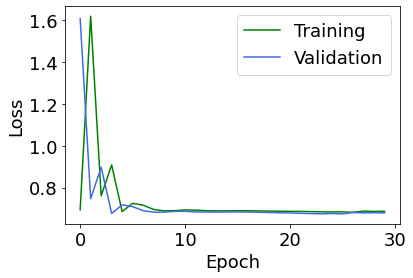

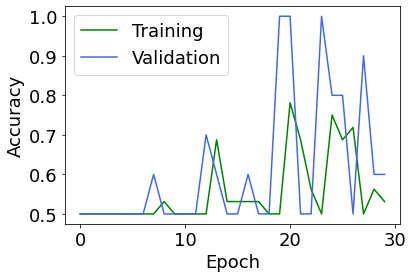

In [13]:
# Plot learning result
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))
plt.plot(epochs, loss, 'b', label='Training', color='green')
plt.plot(epochs, val_loss, 'b', label='Validation', color='royalblue')
#plt.title('Training and Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.figure()
plt.plot(epochs, acc, 'b', label='Training', color='green')
plt.plot(epochs, val_acc, 'b', label='Validation', color='royalblue')
#plt.title('Training and Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [14]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_loss.npy", np.array(loss))
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_loss.npy", np.array(val_loss))

In [15]:
model = load_model(model_file_path)

In [16]:
#model = load_model("D:/Python_TK_3/datas/250422_RNN/shap01/250422_01_best_model_GRU.h5")

In [17]:
# Calcurate accuracy
model.evaluate(input_test,testY)

10/10 [==============================] - 0s 9ms/sample - loss: 0.6696 - acc: 0.8000


[0.6695826053619385, 0.8]

In [18]:
# Predict
train_pred = model.predict(input_train)
valid_pred = model.predict(input_valid)
test_pred = model.predict(input_test)

In [19]:
# Label
train_target = trainY
valid_target = validY
test_target = testY

In [20]:
prediction_frames = 24
print(prediction_frames)

24


In [21]:
# 初期値
#start_value = -0.5 + (look_frame/fs)
start_value = -0.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = prediction_frames

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [22]:
# 初期値
start_value = 0.0 + (look_frame/fs)

# 増加量
increment = 1/fs

# 繰り返し回数
count = prediction_frames

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [23]:
plt.figure(figsize=(20, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(6, 5, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, test_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

<Figure size 1440x1440 with 0 Axes>

In [24]:
plt.figure(figsize=(20, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(valid_target.shape[0]/prediction_frames)):
    plt.subplot(7, 5, ex+1)
    plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, valid_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

<Figure size 1440x1440 with 0 Axes>

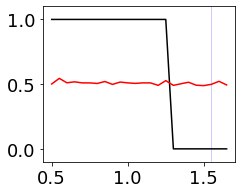

In [25]:
plt.figure(figsize=(20, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(train_target.shape[0]/prediction_frames)):
    plt.subplot(6, 5, ex+1)
    plt.plot(t, train_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, train_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [26]:
# Plot ROC curve
def plot_roc(y_pred, y_test, mode):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
    AUC = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label="AUC = {:.3f}".format(AUC))
    plt.title(mode + " ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    print('AUC: {:.3f}'.format(AUC))
    opt_thr = thresholds[numpy.argmax(tpr - fpr)]
    print('Optimal threshold: {:.3f}'.format(opt_thr))
    return fpr, tpr, opt_thr

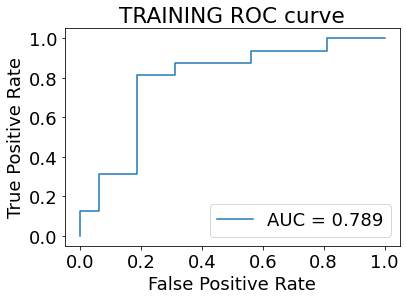

AUC: 0.789
Optimal threshold: 0.505


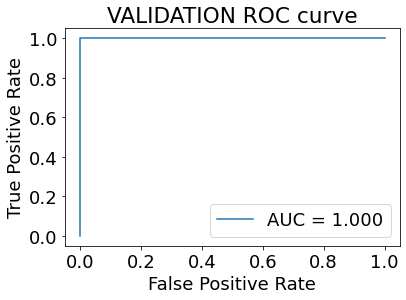

AUC: 1.000
Optimal threshold: 0.507


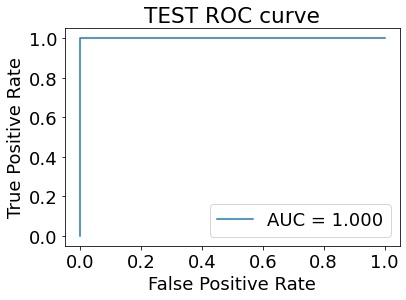

AUC: 1.000
Optimal threshold: 0.512


In [27]:
train_fpr, train_tpr, train_thr = plot_roc(train_pred, train_target, "TRAINING")
valid_fpr, valid_tpr, valid_thr = plot_roc(valid_pred, valid_target, "VALIDATION")
test_fpr, test_tpr, test_thr   = plot_roc(test_pred, test_target, "TEST")

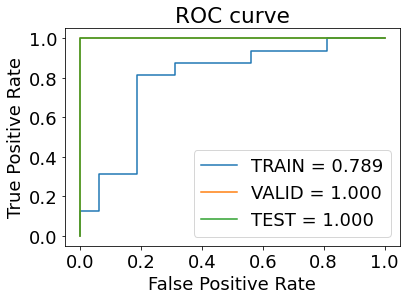

In [28]:
AUC = roc_auc_score(train_target, train_pred)
plt.plot(train_fpr, train_tpr, label="TRAIN = {:.3f}".format(AUC))
AUC = roc_auc_score(valid_target, valid_pred)
plt.plot(valid_fpr, valid_tpr, label="VALID = {:.3f}".format(AUC))
AUC = roc_auc_score(test_target, test_pred)
plt.plot(test_fpr, test_tpr, label="TEST = {:.3f}".format(AUC))
plt.title("ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [29]:
classified_train_pred = []
for f in range(train_pred.shape[0]):
    if train_pred[f, 0] > train_thr:
        classified_train_pred.append(1)
    else:
        classified_train_pred.append(0)

classified_train_pred = np.array(classified_train_pred)
print(classified_train_pred.shape)

(32,)


In [30]:
classified_valid_pred = []
for f in range(valid_pred.shape[0]):
    if valid_pred[f, 0] > valid_thr:
        classified_valid_pred.append(1)
    else:
        classified_valid_pred.append(0)

classified_valid_pred = np.array(classified_valid_pred)
print(classified_valid_pred.shape)

(10,)


In [31]:
classified_test_pred = []
for f in range(test_pred.shape[0]):
    if test_pred[f, 0] > test_thr:
        classified_test_pred.append(1)
    else:
        classified_test_pred.append(0)

classified_test_pred = np.array(classified_test_pred)
print(classified_test_pred.shape)

(10,)


In [32]:
plt.figure(figsize=(30, 10))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(2, 5, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_test_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

<Figure size 2160x720 with 0 Axes>

In [33]:
plt.figure(figsize=(30, 10))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(valid_target.shape[0]/prediction_frames)):
    plt.subplot(2, 5, ex+1)
    plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(1.55, 1.55, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

<Figure size 2160x720 with 0 Axes>

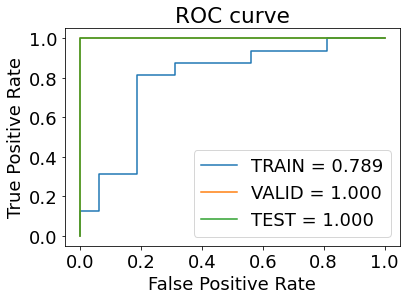

In [34]:
AUC = roc_auc_score(train_target, train_pred)
plt.plot(train_fpr, train_tpr, label="TRAIN = {:.3f}".format(AUC))
AUC = roc_auc_score(valid_target, valid_pred)
plt.plot(valid_fpr, valid_tpr, label="VALID = {:.3f}".format(AUC))
AUC = roc_auc_score(test_target, test_pred)
plt.plot(test_fpr, test_tpr, label="TEST = {:.3f}".format(AUC))
plt.title("ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

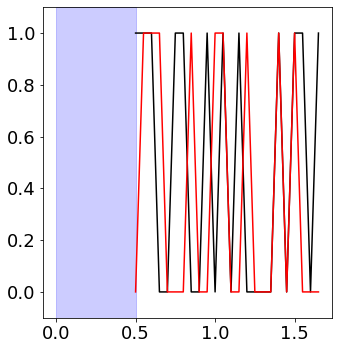

In [35]:
plt.figure(figsize=(30, 40))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(train_target.shape[0]/prediction_frames)):
    plt.subplot(6, 5, ex+1)
    plt.plot(t, train_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_train_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(0.0, 0.5, color='blue', alpha=0.2)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [36]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_truth_train.npy", train_target)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_prediction_train.npy", train_pred)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_truth_valid.npy", valid_target)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_prediction_valid.npy", valid_pred)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_truth_test.npy", test_target)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_prediction_test.npy", test_pred)

In [37]:
import tqdm

shap_vals = np.zeros_like(input_test)

bases = []
for ex in tqdm.tqdm(range(len(TEST))):
    ex_frames = int(input_test.shape[0]/len(TEST))
    input_data = input_test[ex*ex_frames:(ex+1)*ex_frames]
    test_pred = model.predict(input_data)
    shap_val, base = calc_shap(input_data, test_pred, model)
    shap_vals[ex*ex_frames:(ex+1)*ex_frames] = np.array(shap_val)
    bases.append(base)
    
base = np.mean(bases)

100%|██████████| 8/8 [00:22<00:00,  2.75s/it]


In [38]:
io.savemat(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_{ver}.mat", {"base":base, "shap":shap_vals, "pred":test_pred, "label":testY})
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_values.npy", shap_vals)

In [ ]:
stim_frame = int(fs*start_stim)-look_frame

val_loss_before = []
val_loss_after = []
for ex in tqdm.tqdm(range(int(input_valid.shape[0]/prediction_frames))):
    loss_before = np.mean((valid_target[ex*prediction_frames+stim_frame-200:ex*prediction_frames+stim_frame-100]-valid_pred[ex*prediction_frames+stim_frame-200:ex*prediction_frames+stim_frame-100])**2)
    loss_after = np.mean((valid_target[ex*prediction_frames+stim_frame:ex*prediction_frames+stim_frame+100]-valid_pred[ex*prediction_frames+stim_frame:ex*prediction_frames+stim_frame+100])**2)
    val_loss_before.append(loss_before)
    val_loss_after.append(loss_after)

val_loss_before = np.array(val_loss_before)
val_loss_after  = np.array(val_loss_after)

print(val_loss_before.shape, val_loss_after.shape)